# Exploratory Data Analysis

This notebook investigates the structure of the Amazon Electronics interaction
data before preprocessing and modeling.

## Questions

1. How sparse is the user-item interaction matrix?
2. How is user activity distributed?
3. How is item popularity distributed?
4. How are ratings distributed?
5. How substantial is the item cold-start problem?

The analysis uses the temporal split defined:

- Training: <= 2021
- Validation: 2022
- Test: 2023

Item cold-start cohorts are defined exclusively from training-period
interactions.

## 1. User and Item Activity

In [2]:
import duckdb

con = duckdb.connect()

INTERACTIONS_PATH = "../data/processed/electronics_interactions"

query = f"""
SELECT
    COUNT(*) AS interactions,
    COUNT(DISTINCT user_id) AS users,
    COUNT(DISTINCT parent_asin) AS items
FROM '{INTERACTIONS_PATH}/*.parquet'
"""

summary = con.execute(query).df()

summary

,interactions,users,items
0,43365426,18286191,1609860


# Full distribution analysis

In [4]:
import duckdb

con = duckdb.connect()

INTERACTIONS_PATH = "../data/processed/electronics_interactions"

query = f"""
WITH interactions AS (
    SELECT
        user_id,
        parent_asin,
        timestamp,
        EXTRACT(YEAR FROM to_timestamp(timestamp / 1000)) AS year
    FROM '{INTERACTIONS_PATH}/*.parquet'
),

user_activity AS (
    SELECT
        user_id,
        COUNT(*) AS interactions
    FROM interactions
    GROUP BY user_id
),

item_activity AS (
    SELECT
        parent_asin,
        COUNT(*) AS interactions
    FROM interactions
    GROUP BY parent_asin
)

SELECT
    (SELECT COUNT(*) FROM interactions) AS total_interactions,
    (SELECT COUNT(DISTINCT user_id) FROM interactions) AS unique_users,
    (SELECT COUNT(DISTINCT parent_asin) FROM interactions) AS unique_items,

    (SELECT median(interactions)
     FROM user_activity) AS median_user_interactions,

    (SELECT quantile_cont(interactions, 0.90)
     FROM user_activity) AS p90_user_interactions,

    (SELECT median(interactions)
     FROM item_activity) AS median_item_interactions,

    (SELECT quantile_cont(interactions, 0.90)
     FROM item_activity) AS p90_item_interactions
"""

full_summary = con.execute(query).df()
full_summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_interactions,unique_users,unique_items,median_user_interactions,p90_user_interactions,median_item_interactions,p90_item_interactions
0,43365426,18286191,1609860,1.0,5.0,3.0,34.0


# Training Distribution Analysis

In [5]:
query = f"""
WITH interactions AS (
    SELECT
        user_id,
        parent_asin
    FROM '{INTERACTIONS_PATH}/*.parquet'
    WHERE EXTRACT(YEAR FROM to_timestamp(timestamp / 1000)) <= 2021
),

user_activity AS (
    SELECT
        user_id,
        COUNT(*) AS interactions
    FROM interactions
    GROUP BY user_id
),

item_activity AS (
    SELECT
        parent_asin,
        COUNT(*) AS interactions
    FROM interactions
    GROUP BY parent_asin
)

SELECT
    COUNT(*) AS total_interactions,
    COUNT(DISTINCT user_id) AS unique_users,
    COUNT(DISTINCT parent_asin) AS unique_items,

    (SELECT median(interactions)
     FROM user_activity) AS median_user_interactions,

    (SELECT quantile_cont(interactions, 0.90)
     FROM user_activity) AS p90_user_interactions,

    (SELECT median(interactions)
     FROM item_activity) AS median_item_interactions,

    (SELECT quantile_cont(interactions, 0.90)
     FROM item_activity) AS p90_item_interactions

FROM interactions
"""

train_summary = con.execute(query).df()
train_summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_interactions,unique_users,unique_items,median_user_interactions,p90_user_interactions,median_item_interactions,p90_item_interactions
0,37006469,16057140,1394935,1.0,4.0,3.0,33.0


# Histogram plots

In [6]:
query = f"""
SELECT
    parent_asin,
    COUNT(*) AS interaction_count
FROM '{INTERACTIONS_PATH}/*.parquet'
WHERE EXTRACT(YEAR FROM to_timestamp(timestamp / 1000)) <= 2021
GROUP BY parent_asin
"""

item_activity = con.execute(query).df()

item_activity.head()

,parent_asin,interaction_count
0,B07JQWGPYJ,2088
1,B00966IU4M,279
2,B01GTH5Z3E,2840
3,B00WUNEN58,3
4,B08P4WQPVK,23


# Item-count histogram

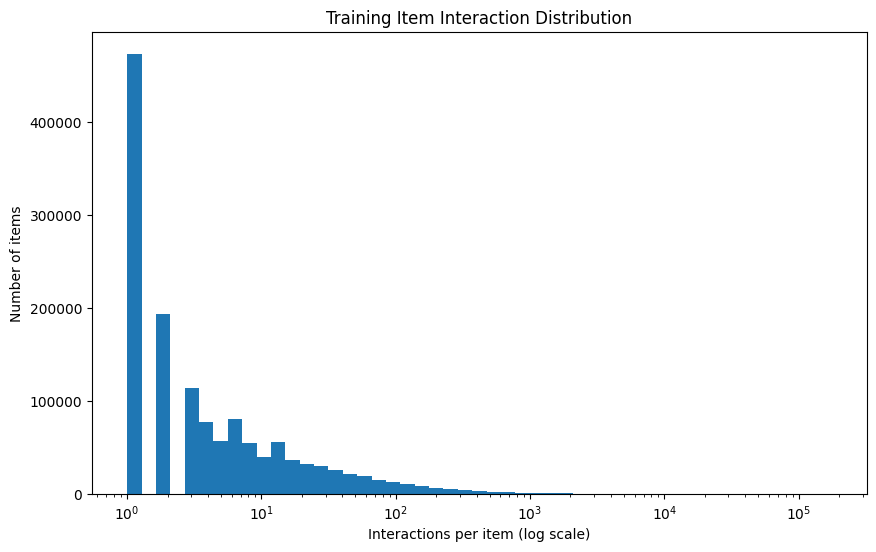

In [10]:
import numpy as np
import matplotlib.pyplot as plt

counts = item_activity["interaction_count"]

log_bins = np.logspace(
    np.log10(counts.min()),
    np.log10(counts.max()),
    50
)

plt.figure(figsize=(10, 6))

plt.hist(
    counts,
    bins=log_bins
)

plt.xscale("log")
plt.xlabel("Interactions per item (log scale)")
plt.ylabel("Number of items")
plt.title("Training Item Interaction Distribution")

plt.show()

# Rank-frequency curve

In [8]:
ranked_items = (
    item_activity
    .sort_values("interaction_count", ascending=False)
    .reset_index(drop=True)
)

ranked_items["rank"] = ranked_items.index + 1

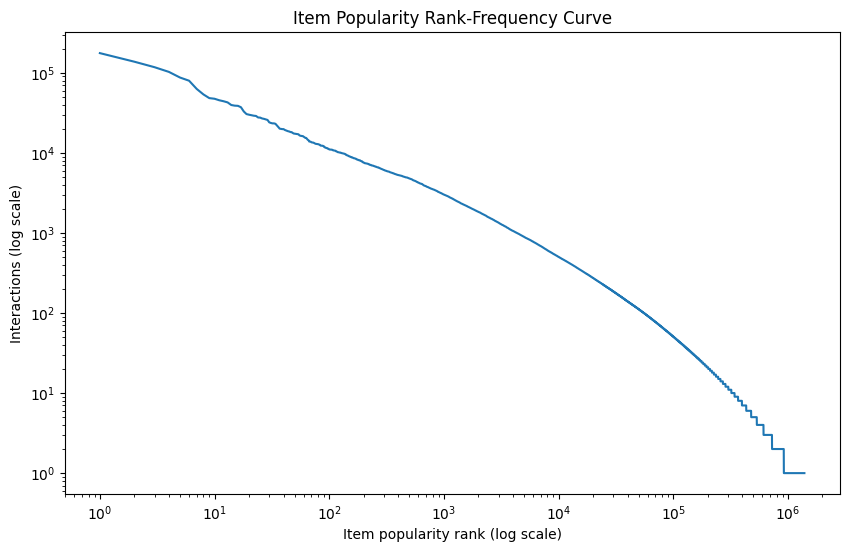

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    ranked_items["rank"],
    ranked_items["interaction_count"]
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Item popularity rank (log scale)")
plt.ylabel("Interactions (log scale)")
plt.title("Item Popularity Rank-Frequency Curve")

plt.show()

### Interpretation

Item interaction frequency is strongly right-skewed and highly long-tailed.
Most items have very little historical interaction data, while a relatively
small number of items receive substantially more interactions.

The rank-frequency curve also shows strong concentration of interaction
activity among highly popular items.

This motivates including popularity as a baseline. Without this baseline,
improvements from more complex recommendation approaches would be difficult
to interpret because they would not be compared against the simplest
strong prior in the dataset.

The long tail also supports the central motivation of this project: interaction
history becomes increasingly sparse for less-established items, creating an
opportunity for product-content signals to provide additional information.

In [11]:
query = f"""
SELECT
    rating,
    COUNT(*) AS interactions,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS percentage
FROM '{INTERACTIONS_PATH}/*.parquet'
WHERE EXTRACT(YEAR FROM to_timestamp(timestamp / 1000)) <= 2021
GROUP BY rating
ORDER BY rating
"""

rating_distribution = con.execute(query).df()

rating_distribution

,rating,interactions,percentage
0,1.0,4285643,11.58
1,2.0,1864074,5.04
2,3.0,2419023,6.54
3,4.0,4840173,13.08
4,5.0,23597556,63.77


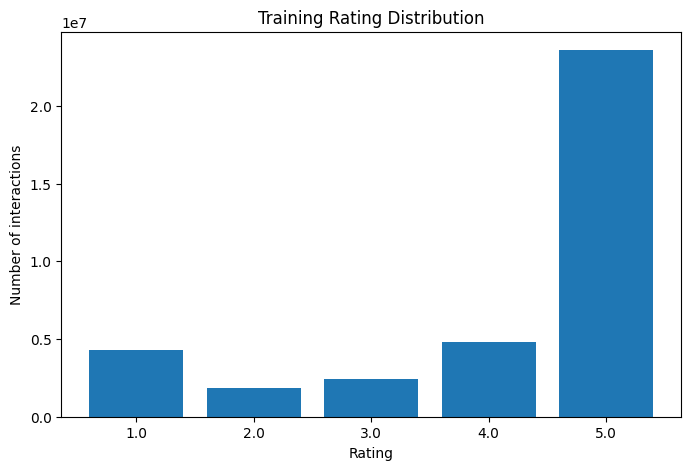

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    rating_distribution["rating"].astype(str),
    rating_distribution["interactions"]
)

plt.xlabel("Rating")
plt.ylabel("Number of interactions")
plt.title("Training Rating Distribution")

plt.show()

### Popularity
How much interaction history does an item have? - COUNT(interactions)

### Relevance
Did the user positively engage with the item? - rating >= 4

In [13]:
query = f"""
SELECT
    user_id,
    COUNT(*) AS interaction_count
FROM '{INTERACTIONS_PATH}/*.parquet'
WHERE EXTRACT(YEAR FROM to_timestamp(timestamp / 1000)) <= 2021
GROUP BY user_id
"""

user_activity = con.execute(query).df()

user_activity.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_id,interaction_count
0,AGJI7NNWXHD5SAUPUFIGPPIO6GMQ,3
1,AH42RUZI432OHV4EYMQGMJMEICFA,1
2,AGMJ4OSCBPXJVFGIGZ6J2WOUZXBA,2
3,AGAGIJ2TCWW7IWGGAHLHECOS7S5Q,1
4,AF5MVD3L7DWEHUZTEZ22A7UGCVTA,1


In [14]:
user_activity["interaction_count"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1.605714e+07
mean     2.304674e+00
std      3.620383e+00
min      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
90%      4.000000e+00
95%      7.000000e+00
99%      1.600000e+01
max      9.420000e+02
Name: interaction_count, dtype: float64

### User-activity

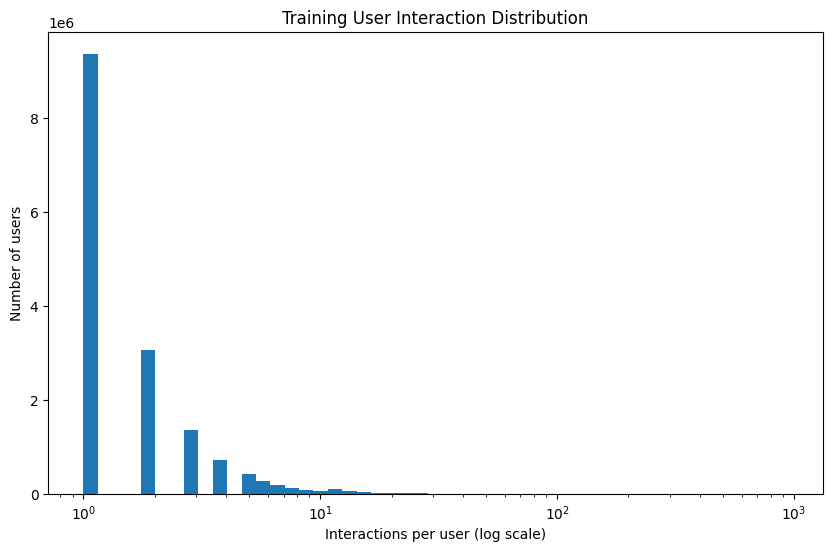

In [15]:
counts = user_activity["interaction_count"]

log_bins = np.logspace(
    np.log10(counts.min()),
    np.log10(counts.max()),
    50
)

plt.figure(figsize=(10, 6))

plt.hist(
    counts,
    bins=log_bins
)

plt.xscale("log")
plt.xlabel("Interactions per user (log scale)")
plt.ylabel("Number of users")
plt.title("Training User Interaction Distribution")

plt.show()

### User-history interpretation

User activity is highly sparse. The median training user has only one
interaction, while 90% of users have four or fewer interactions.

We retain all users rather than filtering users by minimum history. This
preserves the natural sparsity of the dataset and avoids artificially
simplifying the recommendation problem.

User cold-start is not the primary focus of this project; the primary
evaluation remains centered on item cold-start cohorts.

In [16]:
METADATA_PATH = "/home/henry-k/Documents/Projects/cold-start-recommender/data/raw/meta_Electronics.jsonl.gz"

In [17]:
metadata_schema = con.execute(f"""
DESCRIBE
SELECT *
FROM read_json_auto('{METADATA_PATH}')
LIMIT 1
""").df()

metadata_schema

,column_name,column_type,null,key,default,extra
0,main_category,VARCHAR,YES,None,None,None
1,title,VARCHAR,YES,None,None,None
2,average_rating,DOUBLE,YES,None,None,None
3,rating_number,BIGINT,YES,None,None,None
4,features,VARCHAR[],YES,None,None,None
5,description,VARCHAR[],YES,None,None,None
6,price,DOUBLE,YES,None,None,None
7,images,"STRUCT(thumb VARCHAR, ""large"" VARCHAR, variant...",YES,None,None,None
8,videos,"STRUCT(title VARCHAR, url VARCHAR, user_id VAR...",YES,None,None,None
9,store,VARCHAR,YES,None,None,None


In [18]:
query = f"""
SELECT DISTINCT parent_asin
FROM '{INTERACTIONS_PATH}/*.parquet'
"""

catalog_items = con.execute(query).df()

len(catalog_items)

1609860

In [20]:
con.register("catalog_items", catalog_items)

query = f"""
WITH metadata AS (
    SELECT
        parent_asin,
        title,
        description,
        features,
        categories
    FROM read_json_auto('{METADATA_PATH}')
)

SELECT
    COUNT(DISTINCT c.parent_asin) AS catalog_items,
    COUNT(DISTINCT m.parent_asin) AS items_with_metadata,

    COUNT(DISTINCT CASE
        WHEN m.title IS NOT NULL AND TRIM(m.title) <> ''
        THEN c.parent_asin
    END) AS items_with_title,

    COUNT(DISTINCT CASE
        WHEN m.description IS NOT NULL AND len(m.description) > 0
        THEN c.parent_asin
    END) AS items_with_description,

    COUNT(DISTINCT CASE
        WHEN m.features IS NOT NULL AND len(m.features) > 0
        THEN c.parent_asin
    END) AS items_with_features,

    COUNT(DISTINCT CASE
        WHEN m.categories IS NOT NULL AND len(m.categories) > 0
        THEN c.parent_asin
    END) AS items_with_categories

FROM catalog_items c
LEFT JOIN metadata m
    ON c.parent_asin = m.parent_asin
"""

metadata_coverage = con.execute(query).df()
metadata_coverage

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,catalog_items,items_with_metadata,items_with_title,items_with_description,items_with_features,items_with_categories
0,1609860,1609860,1609766,927182,1186857,1481432


In [21]:
query = f"""
WITH train_item_counts AS (
    SELECT
        parent_asin,
        COUNT(*) AS train_interactions
    FROM '{INTERACTIONS_PATH}/*.parquet'
    WHERE EXTRACT(YEAR FROM to_timestamp(timestamp / 1000)) <= 2021
    GROUP BY parent_asin
),

test_items AS (
    SELECT DISTINCT parent_asin
    FROM '{INTERACTIONS_PATH}/*.parquet'
    WHERE EXTRACT(YEAR FROM to_timestamp(timestamp / 1000)) = 2023
),

test_cohorts AS (
    SELECT
        t.parent_asin,
        COALESCE(c.train_interactions, 0) AS train_interactions,
        CASE
            WHEN COALESCE(c.train_interactions, 0) = 0
                THEN 'true_cold'
            WHEN COALESCE(c.train_interactions, 0) BETWEEN 1 AND 5
                THEN 'low_history'
            WHEN COALESCE(c.train_interactions, 0) BETWEEN 6 AND 20
                THEN 'medium_history'
            ELSE 'warm'
        END AS cohort
    FROM test_items t
    LEFT JOIN train_item_counts c
        ON t.parent_asin = c.parent_asin
),

metadata AS (
    SELECT
        parent_asin,
        title,
        description,
        features,
        categories
    FROM read_json_auto('{METADATA_PATH}')
)

SELECT
    tc.cohort,
    COUNT(*) AS items,
    
    ROUND(
        100.0 * COUNT(CASE
            WHEN m.title IS NOT NULL AND TRIM(m.title) <> ''
            THEN 1
        END) / COUNT(*),
        2
    ) AS title_coverage_pct,

    ROUND(
        100.0 * COUNT(CASE
            WHEN m.description IS NOT NULL AND len(m.description) > 0
            THEN 1
        END) / COUNT(*),
        2
    ) AS description_coverage_pct,

    ROUND(
        100.0 * COUNT(CASE
            WHEN m.features IS NOT NULL AND len(m.features) > 0
            THEN 1
        END) / COUNT(*),
        2
    ) AS features_coverage_pct,

    ROUND(
        100.0 * COUNT(CASE
            WHEN m.categories IS NOT NULL AND len(m.categories) > 0
            THEN 1
        END) / COUNT(*),
        2
    ) AS categories_coverage_pct

FROM test_cohorts tc
LEFT JOIN metadata m
    ON tc.parent_asin = m.parent_asin

GROUP BY tc.cohort

ORDER BY
    CASE tc.cohort
        WHEN 'true_cold' THEN 1
        WHEN 'low_history' THEN 2
        WHEN 'medium_history' THEN 3
        WHEN 'warm' THEN 4
    END
"""

cohort_metadata_coverage = con.execute(query).df()
cohort_metadata_coverage

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cohort,items,title_coverage_pct,description_coverage_pct,features_coverage_pct,categories_coverage_pct
0,true_cold,117203,100.0,43.81,92.04,96.95
1,low_history,34984,100.0,56.87,93.16,96.27
2,medium_history,32060,100.0,51.49,94.56,96.79
3,warm,62863,100.0,48.27,96.68,96.95


### Metadata coverage by cold-start cohort

Metadata availability was also evaluated separately for the 2023 test
cohorts, using cohort labels defined exclusively from training-period
interactions.

All test items have a non-empty title. Feature and category coverage is also
high across cohorts, while description coverage is substantially lower.

For true-cold items specifically, title coverage is 100%, feature coverage is
92.04%, category coverage is 96.95%, and description coverage is 43.81%.

This indicates that content-based recommendation is feasible for true-cold
items, but the content representation should be robust to missing fields
rather than depending on descriptions being present for every product.

The final choice of metadata fields and text construction is deferred to
Phase 4, where preprocessing and feature engineering will be designed.